In [2]:
import os, argparse, typing
os.chdir("../")

import numpy as np
import pandas as pd
import torch 

from PINN import models as models
from PINN import reader 
from PINN import functions as fns

import matplotlib.pyplot as plt
import seaborn as sns

In [15]:
from PINN import pl

In [3]:
import scanpy as sc

## prepare the ery_mk anndata for training

In [27]:
ery_mk_ad = sc.read_h5ad("data/ery_mk.h5ad")

In [28]:
ery_mk_ad.uns['pop']

{'mean': array([   68.71174149,   181.0456594 ,   319.71192389,  1033.80104176,
         1221.63752755,  4388.82149907,  6420.56721147,  2300.67040713,
        18898.77670928]),
 'n_lib': array([4, 6, 4, 4, 4, 2, 4, 4, 4]),
 't': array([  3,   7,  12,  27,  49,  76, 112, 161, 269]),
 'var': array([5.64698791e+01, 2.97828935e+02, 7.21614187e+02, 2.48259499e+04,
        2.60310172e+04, 1.62207978e+04, 4.28322705e+05, 1.26096766e+05,
        3.51421915e+05])}

In [29]:
def load_model_DS(ckpt_path):

    modelvx = models.Cspline_PINN.load_from_checkpoint(ckpt_path)
    n_grid = modelvx.n_grid
    nearby_cellstate = 300

    train_DS = reader.MeshGrid_AnnDS(AnnData=ery_mk_ad, cellstate_key='Actb_Kcnn4_scaled_S',
                                    n_grid=n_grid,  nearby_cellstate=nearby_cellstate, 
                                    collocation_points=300, n_repeat=10)
    
    return modelvx, train_DS

def predict_u(model, train_DS):
    
    s = train_DS.s
    ub_pred = []
    
    with torch.no_grad():
        for tb in train_DS.t_b:
            
            device = model.device
            tb = torch.from_numpy(tb).float()
    
            u_pred_t = model.u(s.to(device), tb.to(device))
            ub_pred.append( u_pred_t.cpu().numpy() )
    
    torch.cuda.empty_cache()
    ub_pred = np.array(ub_pred)
    
    return ub_pred

```python
n_lib = []
for t_b in D['pop']['t']:
    tp_index = [i for i, t in enumerate(D['ind']['tp']) if t==t_b]      
    n_lib.append( len(tp_index) )
D['pop']['n_lib'] = np.array(n_lib)
ery_mk_ad.uns['pop'] = D['pop']
ery_mk_ad.uns['pop']
ery_mk_ad.uns['pop']['t'] = ery_mk_ad.uns['pop']['t'] + 3
ery_mk_ad.obs['timepoint'] = ery_mk_ad.obs['timepoint_tx_days']
ery_mk_ad.write_h5ad("data/ery_mk.h5ad")
```

# load the training DS and model

### version 1

In [5]:
# add the datasets
# 
# some hyper params 
n_grid = 50
nearby_cellstate = 50

train_DS = reader.MeshGrid_AnnDS(AnnData=ery_mk_ad, cellstate_key='Actb_Kcnn4_scaled_S',
                                    n_grid=n_grid,  nearby_cellstate=nearby_cellstate, 
                                    collocation_points=300, n_repeat=10)

# get msh grid cell state
s = train_DS.s
ub = train_DS.u_b

In [28]:
print(ub.shape)

(9, 2500)


In [6]:
n_dim = 2
coords = [np.linspace(0.01, 0.99, n_grid) for i in range(n_dim)]  # generate 1D uniform coord
meshgrid = np.meshgrid(*coords)

In [14]:
s = train_DS.s
X = s[:,0].reshape(n_grid,n_grid)
Y = s[:,1].reshape(n_grid,n_grid)

XX,YY = meshgrid

In [17]:
modelv1 = models.Cspline_PINN.load_from_checkpoint("logs/ery_mk-Actb_Kcnn4_scaled_S_multiBnch/lightning_logs/version_1/checkpoints/epoch=128-total_loss=0.42387700.ckpt")

/home/wergillius/.conda/envs/PINN_torch/lib/python3.9/site-packages/pytorch_lightning/utilities/parsing.py:208: Attribute 'u' is an instance of `nn.Module` and is already saved during checkpointing. It is recommended to ignore them using `self.save_hyperparameters(ignore=['u'])`.


In [36]:
modelv1.u.u_theta

Sequential(
  (Linear_0): Linear(in_features=3, out_features=32, bias=True)
  (Tanh_0): Tanh()
  (Linear_1): Linear(in_features=32, out_features=32, bias=True)
  (Tanh_1): Tanh()
  (Linear_2): Linear(in_features=32, out_features=1, bias=True)
)

### visualize for v1

In [45]:
import matplotlib.pyplot as plt

Text(0, 0.5, 'Kcnn4')

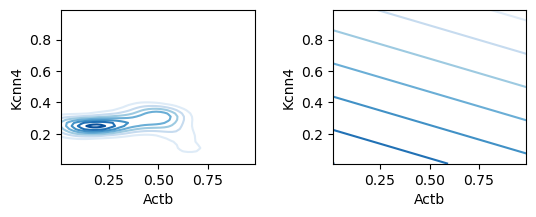

In [58]:
cellstate_1 = 'Actb'
cellstate_2 = 'Kcnn4'

fig, axs = plt.subplots(1,2, figsize=(6,2), gridspec_kw={'wspace':0.4})

Z_ub = ub[0].reshape(n_grid, n_grid)
axs[0].contour(XX,YY, Z, cmap='Blues')

Z_pred = u_b_pred[0].reshape(n_grid, n_grid)
axs[1].contour(XX,YY, Z_pred, cmap='Blues')

axs[0].set_xlabel(cellstate_1)
axs[0].set_ylabel(cellstate_2)

axs[1].set_xlabel(cellstate_1)
axs[1].set_ylabel(cellstate_2)

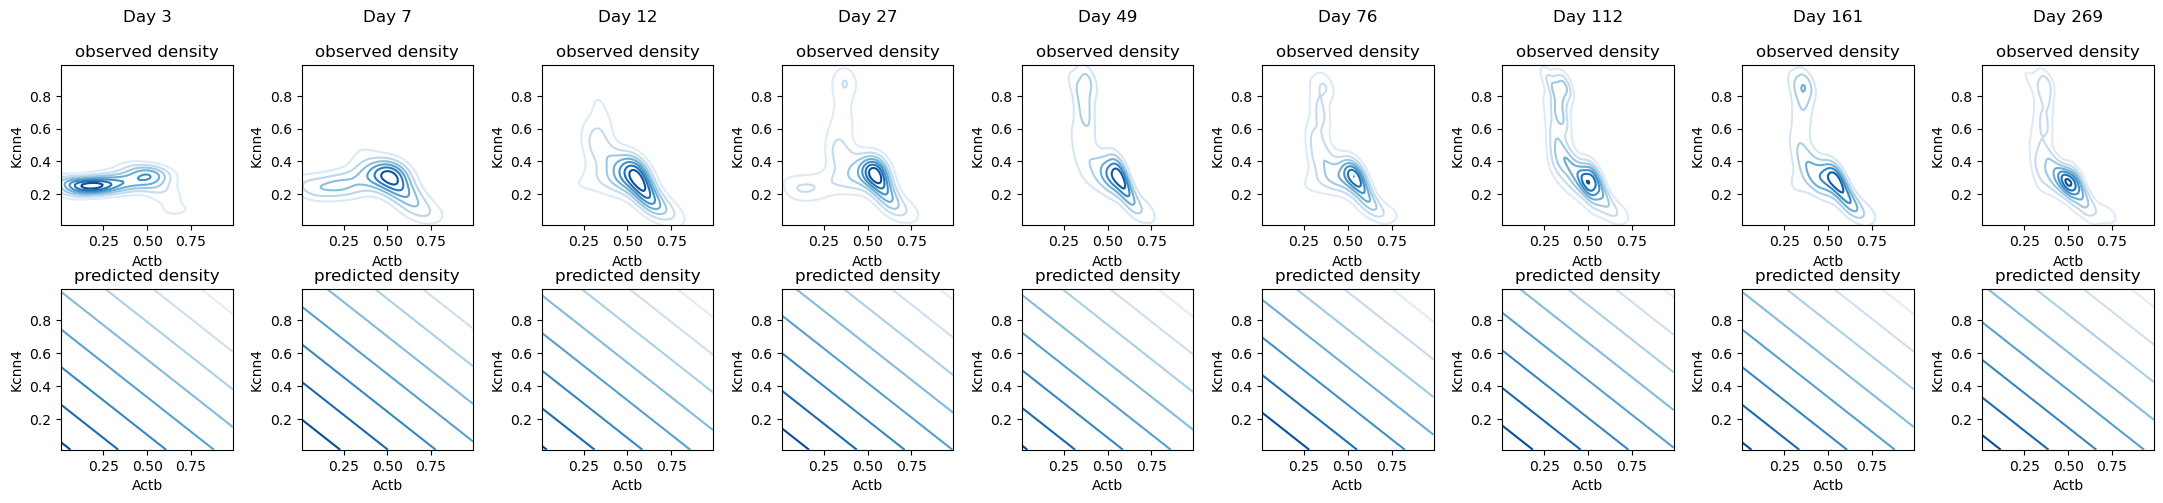

In [15]:
fig, axs= pl.meshgrid_density_by_time(ub, ub_pred, train_DS, cellstate_1 = 'Actb', cellstate_2 = 'Kcnn4')

## Version 4

In [17]:

v4ckpt = "logs/ery_mk-Actb_Kcnn4_scaled_S_multiBnch/lightning_logs/version_4/checkpoints/epoch=82-total_loss=0.42214251.ckpt"

modelv4, train_DS = load_model_DS(v4ckpt)

/ssd/users/Wergillius/miniforge3/envs/PINN_torch/lib/python3.9/site-packages/pytorch_lightning/utilities/parsing.py:208: Attribute 'u' is an instance of `nn.Module` and is already saved during checkpointing. It is recommended to ignore them using `self.save_hyperparameters(ignore=['u'])`.
/ssd/users/Wergillius/Project/PINN_dynamics/PINN/reader.py:49: RuntimeWarning: invalid value encountered in log
  self.popD['mean'] = np.log(mu)


In [18]:
ub_pred = predict_u(modelv4, train_DS)
ub = train_DS.u_b

In [21]:
train_DS

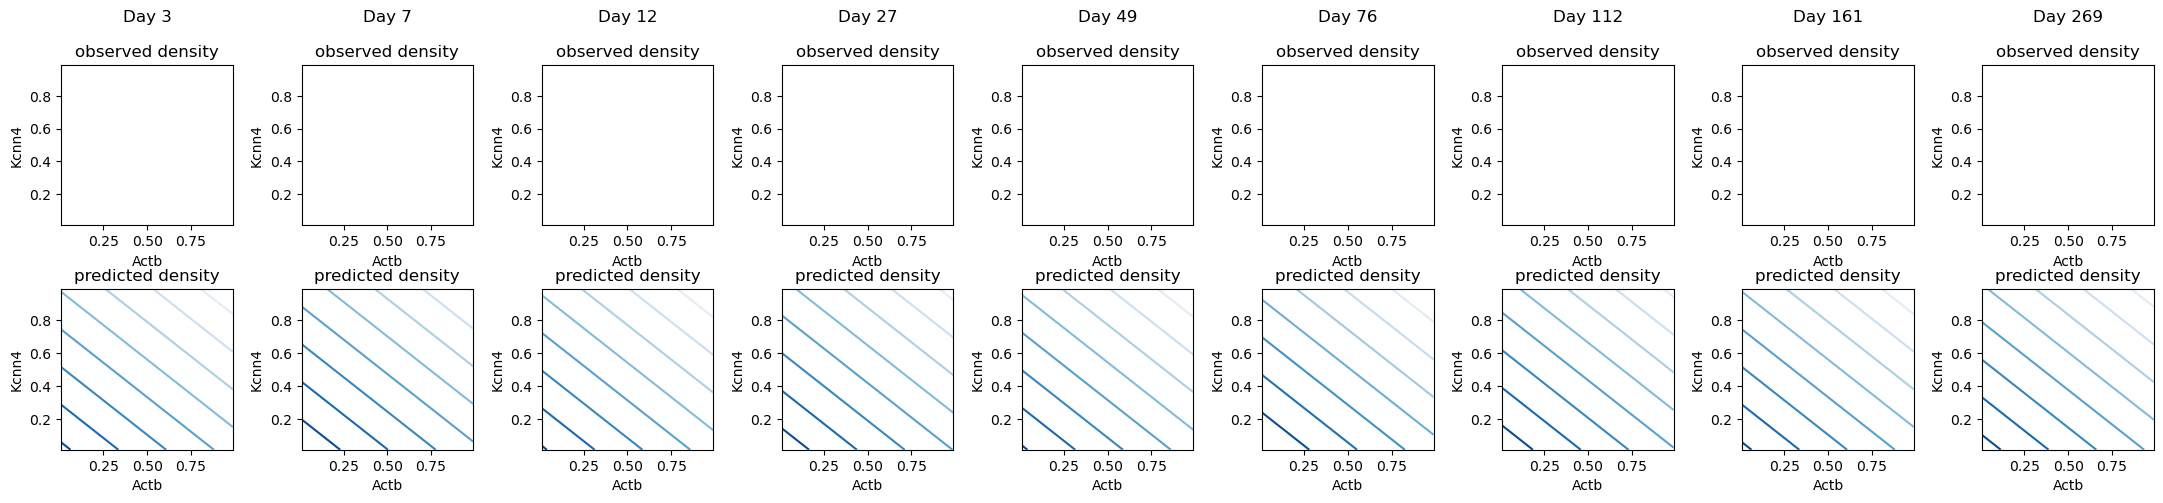

In [19]:
fig, axs= pl.meshgrid_density_by_time(ub, ub_pred, train_DS, cellstate_1 = 'Actb', cellstate_2 = 'Kcnn4')

## Version 5

In [30]:

v5ckpt = "logs/ery_mk-Actb_Kcnn4_scaled_S_multiBnch/lightning_logs/version_5/checkpoints/epoch=117-total_loss=0.42218018.ckpt"
modelv5, train_DS = load_model_DS(v5ckpt)

ub_pred = predict_u(modelv5, train_DS)
ub = train_DS.u_b

/ssd/users/Wergillius/miniforge3/envs/PINN_torch/lib/python3.9/site-packages/pytorch_lightning/utilities/parsing.py:208: Attribute 'u' is an instance of `nn.Module` and is already saved during checkpointing. It is recommended to ignore them using `self.save_hyperparameters(ignore=['u'])`.


In [31]:
train_DS.popD['mean']

array([4.22992009, 5.19874926, 5.76742035, 6.94099762, 7.10794747,
       8.38681602, 8.76726174, 7.74095584, 9.84685247])

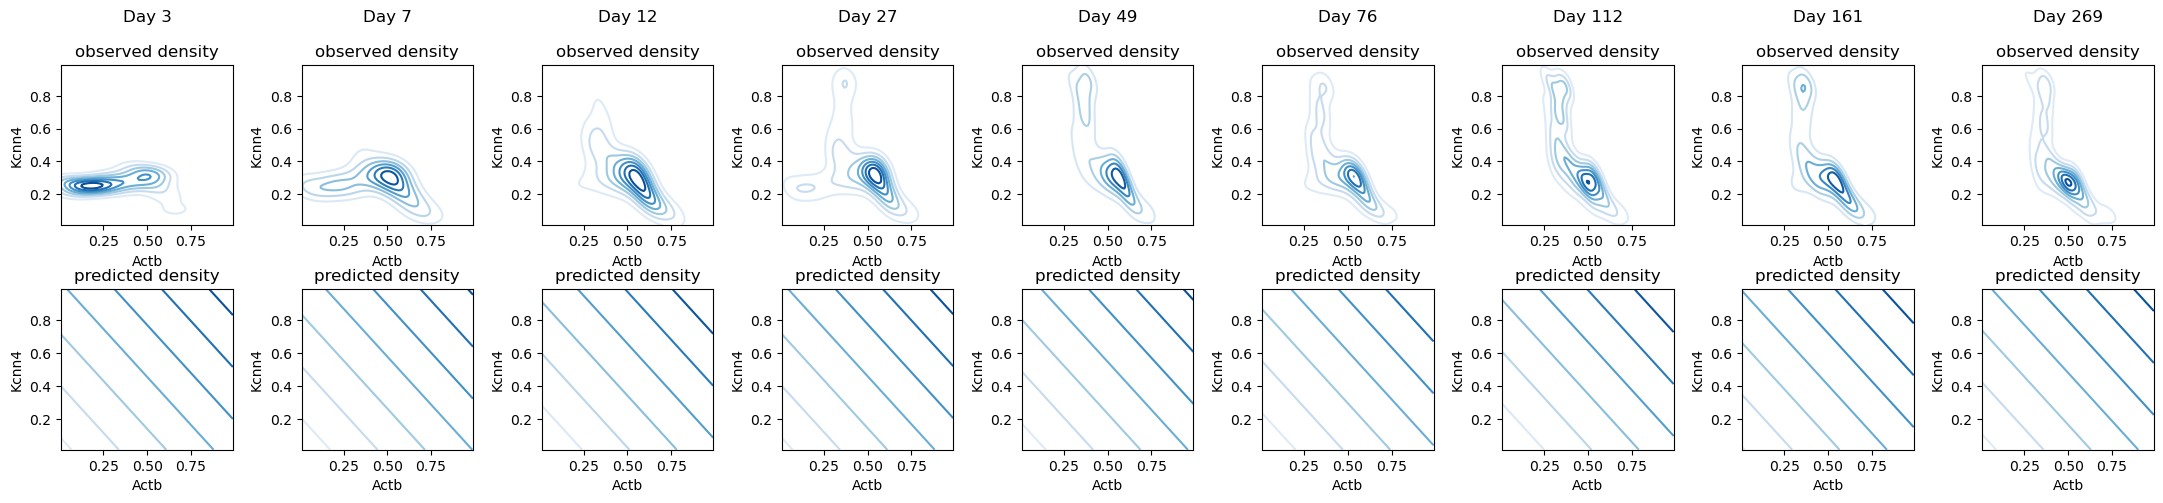

In [32]:
fig, axs= pl.meshgrid_density_by_time(ub, ub_pred, train_DS, cellstate_1 = 'Actb', cellstate_2 = 'Kcnn4')

## version 6

/ssd/users/Wergillius/miniforge3/envs/PINN_torch/lib/python3.9/site-packages/pytorch_lightning/utilities/parsing.py:208: Attribute 'u' is an instance of `nn.Module` and is already saved during checkpointing. It is recommended to ignore them using `self.save_hyperparameters(ignore=['u'])`.


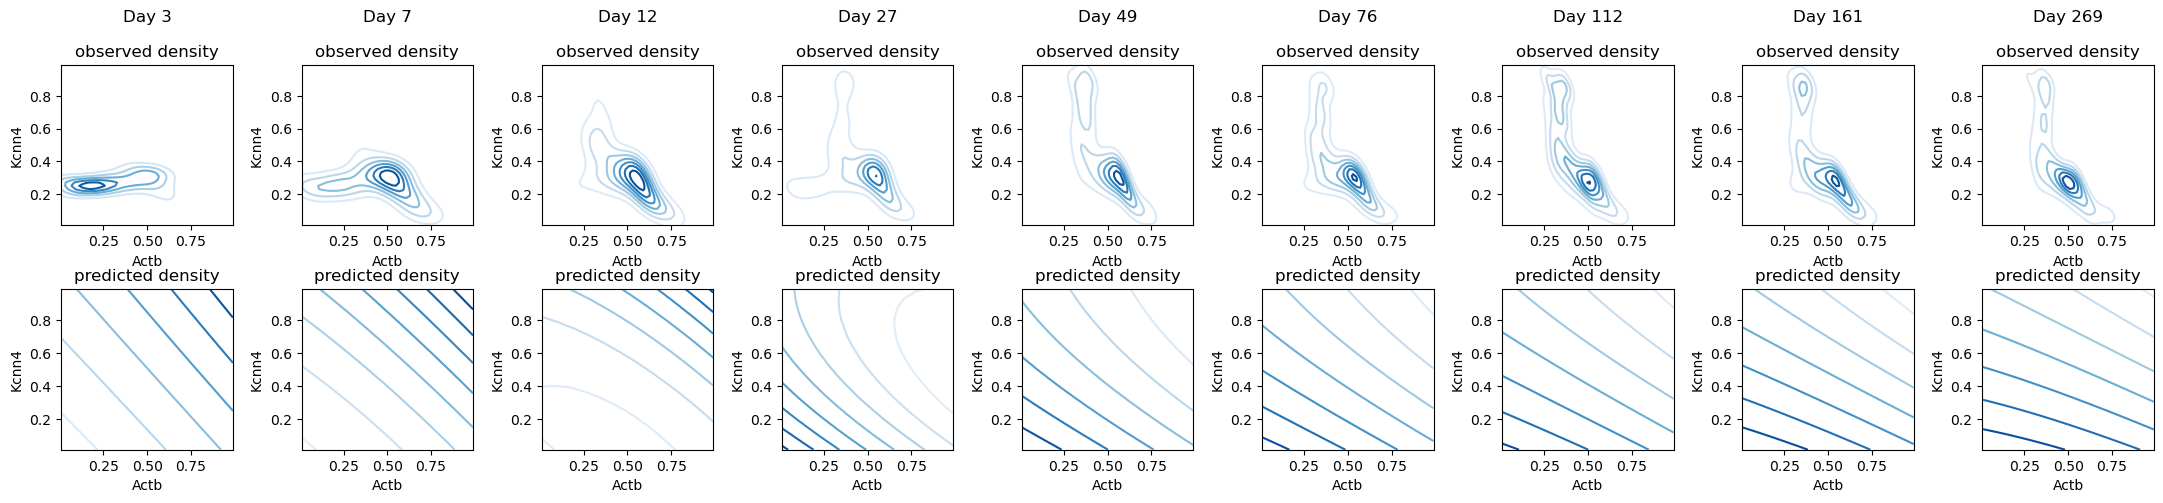

In [38]:
v6_ckpt = "logs/ery_mk-Actb_Kcnn4_scaled_S_multiBnch/lightning_logs/version_6/checkpoints/epoch=59-total_loss=0.42216381.ckpt"

modelv6, train_DS = load_model_DS(v6_ckpt)

ub_pred = predict_u(modelv6, train_DS)
ub = train_DS.u_b

fig, axs= pl.meshgrid_density_by_time(ub, ub_pred, train_DS, cellstate_1 = 'Actb', cellstate_2 = 'Kcnn4')

In [43]:
ery_mk_ad.uns['pop'].copy(), train_DS.popD['var']

({'mean': array([1.4421831 , 1.64841807, 1.7522249 , 1.93744551, 1.96121352,
         2.12666095, 2.17102453, 2.04652517, 2.28715186]),
  'n_lib': array([4, 6, 4, 4, 4, 2, 4, 4, 4]),
  't': array([  3,   7,  12,  27,  49,  76, 112, 161, 269]),
  'var': array([0.19429147, 0.31643164, 0.39134936, 3.45976828, 2.99781317,
         0.44068389, 7.60910763, 7.0803537 , 1.88841619])},
 array([0.19429147, 0.31643164, 0.39134936, 3.45976828, 2.99781317,
        0.44068389, 7.60910763, 7.0803537 , 1.88841619]))

## version 6

/ssd/users/Wergillius/miniforge3/envs/PINN_torch/lib/python3.9/site-packages/pytorch_lightning/utilities/parsing.py:208: Attribute 'u' is an instance of `nn.Module` and is already saved during checkpointing. It is recommended to ignore them using `self.save_hyperparameters(ignore=['u'])`.


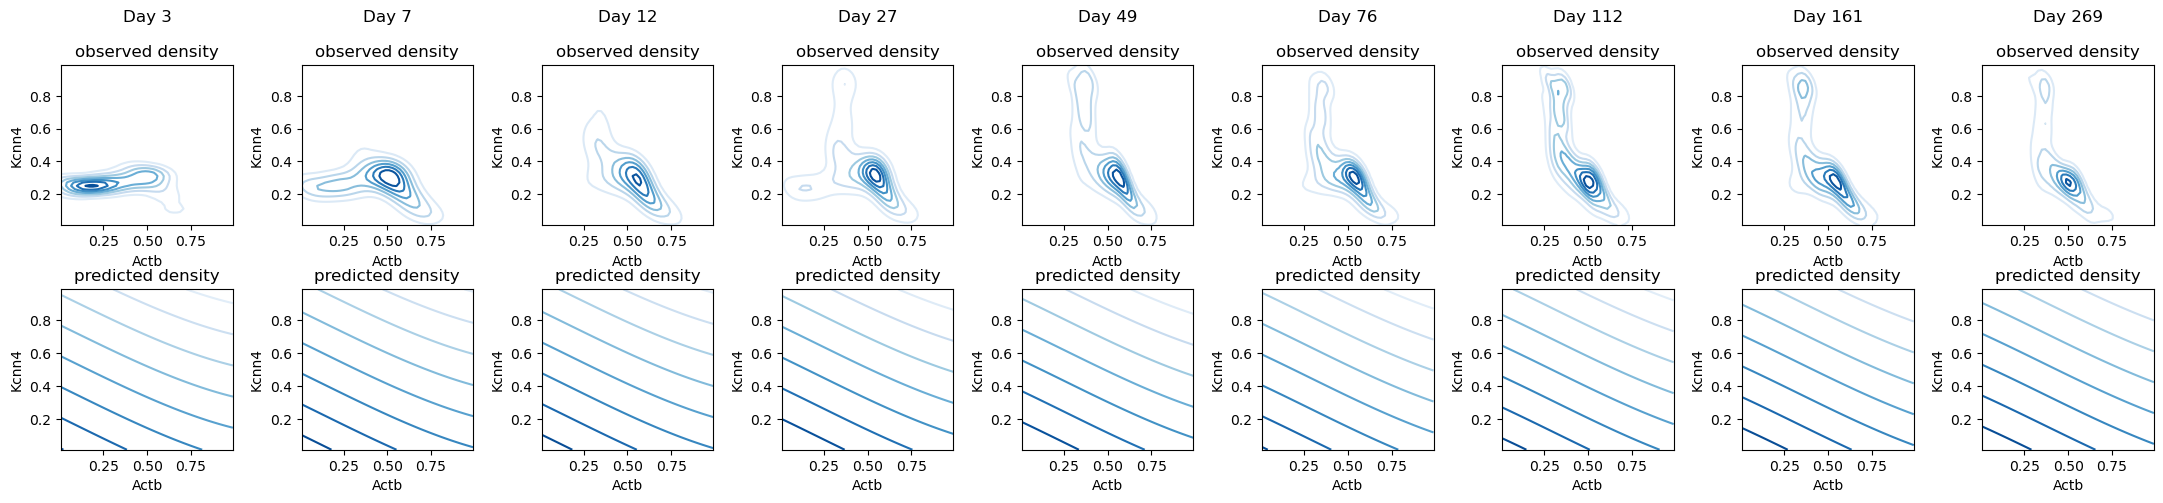

In [44]:
v7_ckpt = "logs/ery_mk-Actb_Kcnn4_scaled_S_multiBnch/lightning_logs/version_7/checkpoints/epoch=157-total_loss=0.42216381.ckpt"

modelv7, train_DS = load_model_DS(v7_ckpt)

ub_pred7 = predict_u(modelv7, train_DS)
ub7 = train_DS.u_b

fig, axs= pl.meshgrid_density_by_time(ub7, ub_pred7, train_DS, cellstate_1 = 'Actb', cellstate_2 = 'Kcnn4')

In [46]:
ub.shape

(9, 2500)

In [51]:
ub = ub / ub.sum(axis=1, keepdims=True)

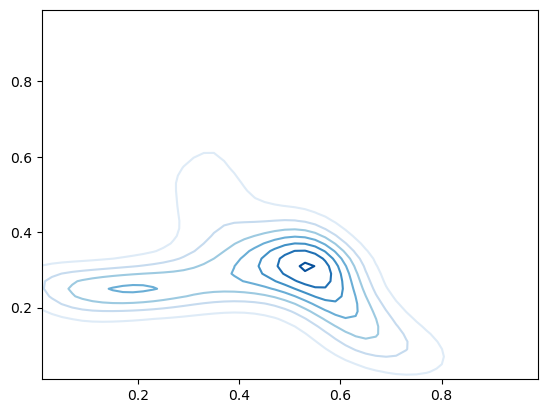

In [53]:
n_grid = 50
s = train_DS.s
XX = s[:,0].reshape(n_grid,n_grid)    # in DS, meshgrid is flatten
YY = s[:,1].reshape(n_grid,n_grid)
Z_ub = ub[:4,].mean(axis=0).reshape(n_grid, n_grid)
plt.contour(XX,YY, Z_ub, cmap='Blues')